In [67]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.signal import butter, sosfiltfilt
import scipy

if __package__ in {None, ""}:
    sys.path.insert(0, str(Path("../").resolve()))

from backend.mag_to_travel_model_core import MagToTravelChunk, MagToTravelModelCore

In [68]:
log_filename = "log136_rear"

In [69]:
out_dir = f"../backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])
accel_idx = "2"
a = ws[f"accel/lpf/lis{accel_idx}__x"]
b_raw = ws["mag/lpf__x"]
b2_raw = ws["mag_lis/lpf__x"]
b_diff = ws["mag_diff/lpf__x"]
b_proj = ws["mag/proj/lpf__x"][:, 0]
gyro = ws[f"gyro/lpf/gyro{accel_idx}__x"]
t = ws[f"accel/lpf/lis{accel_idx}__t"]
travel = ws["travel__x"][:, 0]

v_gt = np.gradient(travel, t, edge_order = 2)
a_gt = np.gradient(v_gt, t, edge_order = 2) / 1000.0

['__log_config_hash', 'accel/lis1__t', 'accel/lis1__x', 'gyro/gyro1__t', 'gyro/gyro1__x', 'accel/lis2__t', 'accel/lis2__x', 'gyro/gyro2__t', 'gyro/gyro2__x', 'mag__t', 'mag__x', 'mag_lis__t', 'mag_lis__x', 'angle__t', 'angle__x', 'angle/bad_mask__t', 'angle/bad_mask__x', 'gyro/lpf/gyro1__t', 'gyro/lpf/gyro1__x', 'gyro/lpf/gyro2__t', 'gyro/lpf/gyro2__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'mag/lpf__t', 'mag/lpf__x', 'mag_lis/lpf__t', 'mag_lis/lpf__x', 'mag_diff__t', 'mag_diff__x', 'mag_diff/lpf__t', 'mag_diff/lpf__x', 'mag/proj__t', 'mag/proj__x', 'mag/proj/lpf__t', 'mag/proj/lpf__x', 'mag_zv_points']


In [70]:
# Get mag norm and polar coords
def get_polar(vec):
    mag =  np.linalg.norm(vec, axis=1)
    normed = (vec.T / mag).T
    theta = np.degrees(np.atan2(normed[:, 1], normed[:, 0]))
    phi = np.degrees(np.arcsin(normed[:, 2]))
    return mag, theta, phi

b1_mag, b1_theta, b1_phi = get_polar(b_raw)
b2_mag, b2_theta, b2_phi = get_polar(b2_raw)

# MMC Y is -LIS X
# MMC X is LIS Y
lis_rot = [[0, 1, 0],
           [-1, 0, 0],
           [0, 0, 1]]
lis_rot = np.asarray(lis_rot)

b2_rot = (lis_rot @ b2_raw.T).T
print(b2_raw[:10])
print(b2_rot[:10])
print(b_raw[:10])
b_corr = b_diff#b_raw - b2_rot
b_corr_mag = np.linalg.norm(b_corr, axis=1)

[[   80.97468718 -1339.01033301  -840.98247793]
 [   82.45278843 -1338.40828585  -841.27164083]
 [   83.62151357 -1337.73137667  -841.50014563]
 [   84.26270792 -1336.97372382  -841.6040189 ]
 [   84.319537   -1336.22257277  -841.51157233]
 [   83.89615047 -1335.6422402   -841.13589587]
 [   83.20171672 -1335.41234601  -840.38916024]
 [   82.46311196 -1335.64775921  -839.22624004]
 [   81.84229183 -1336.33999439  -837.69885672]
 [   81.3960131  -1337.34759188  -835.98578206]]
[[-1339.01033301   -80.97468718  -840.98247793]
 [-1338.40828585   -82.45278843  -841.27164083]
 [-1337.73137667   -83.62151357  -841.50014563]
 [-1336.97372382   -84.26270792  -841.6040189 ]
 [-1336.22257277   -84.319537    -841.51157233]
 [-1335.6422402    -83.89615047  -841.13589587]
 [-1335.41234601   -83.20171672  -840.38916024]
 [-1335.64775921   -82.46311196  -839.22624004]
 [-1336.33999439   -81.84229183  -837.69885672]
 [-1337.34759188   -81.3960131   -835.98578206]]
[[ 1862.021135   -8258.99959226 -1295.

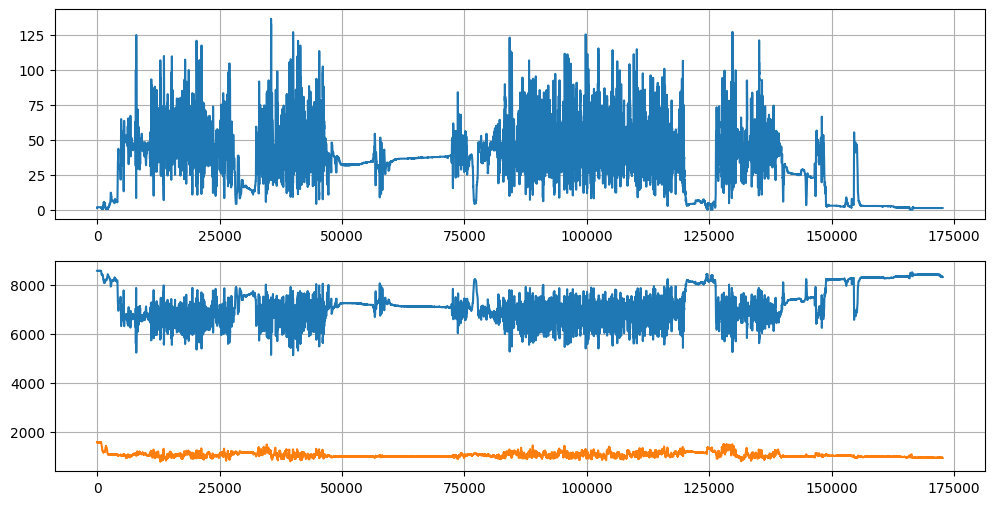

In [71]:
# Plot travel, mag norm
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(travel)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(b1_mag)
plt.plot(b2_mag)
plt.grid()

-0.9772317731561122 -0.9817416245482508
-0.9848067148320359 -0.9903977791581785
-0.984913762300952 -0.9904018216635431


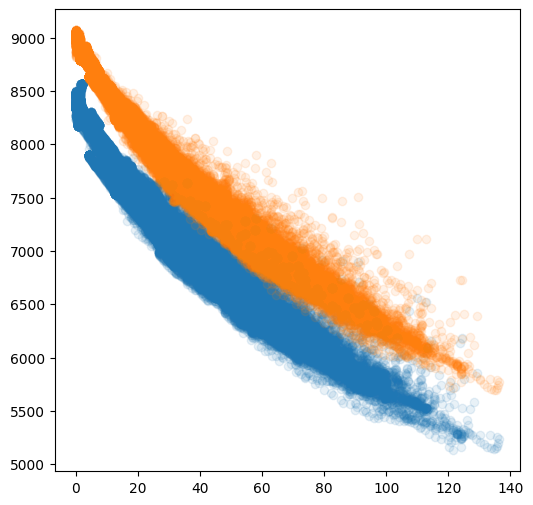

In [72]:
# Plot angle vs mag norm
plt.figure(figsize=(6, 6))
plt.scatter(travel, b1_mag, alpha=0.1)
plt.scatter(travel, b_proj, alpha=0.1)
corr = scipy.stats.pearsonr(travel, b1_mag)
spearman = scipy.stats.spearmanr(travel, b1_mag)
print(corr[0], spearman.correlation)
corr = scipy.stats.pearsonr(travel, b_corr_mag)
spearman = scipy.stats.spearmanr(travel, b_corr_mag)
print(corr[0], spearman.correlation)
corr = scipy.stats.pearsonr(travel, b_proj)
spearman = scipy.stats.spearmanr(travel, b_proj)
print(corr[0], spearman.correlation)

In [73]:
roi = slice(0, -1)
roi = slice(19400, 20000)

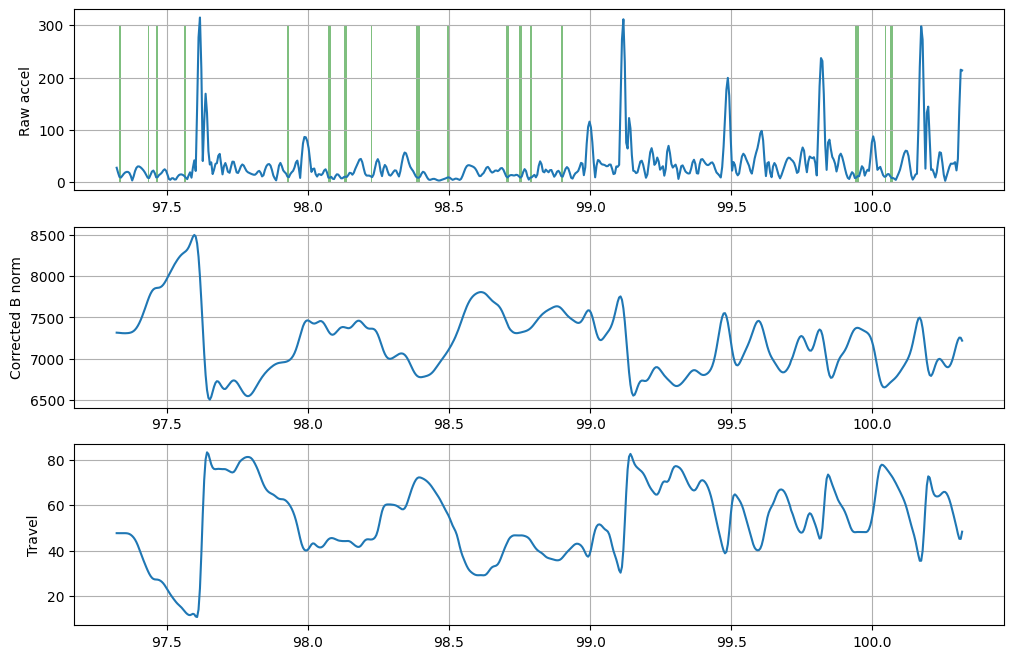

In [74]:
# Plot accelerometer, travel, mag data

a_norm = np.linalg.norm(a, axis=1)
near_grav = (a_norm < 11.8) & (a_norm > 7.8)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.ylabel("Raw accel")
plt.plot(t[roi], a_norm[roi])
ax = plt.gca()
ax.fill_between(t[roi], 300, where=near_grav[roi], facecolor='green', alpha=.5)
plt.grid()
plt.subplot(3, 1, 2)
plt.ylabel("Corrected B norm")
plt.plot(t[roi], b_corr_mag[roi])
plt.grid()
plt.subplot(3, 1, 3)
plt.ylabel("Travel")
plt.plot(t[roi], travel[roi])
plt.grid()


Travel-correlated accel axis: [-0.36258922 -0.93053405  0.05133656]
Main accel axis: [-0.25681215 -0.96585725  0.03416576]
Accel MA, RMS: 6.788998609334663 20.0507168616717
Accel error MAE, RMSE: 8.66121898110806 17.70782348166218


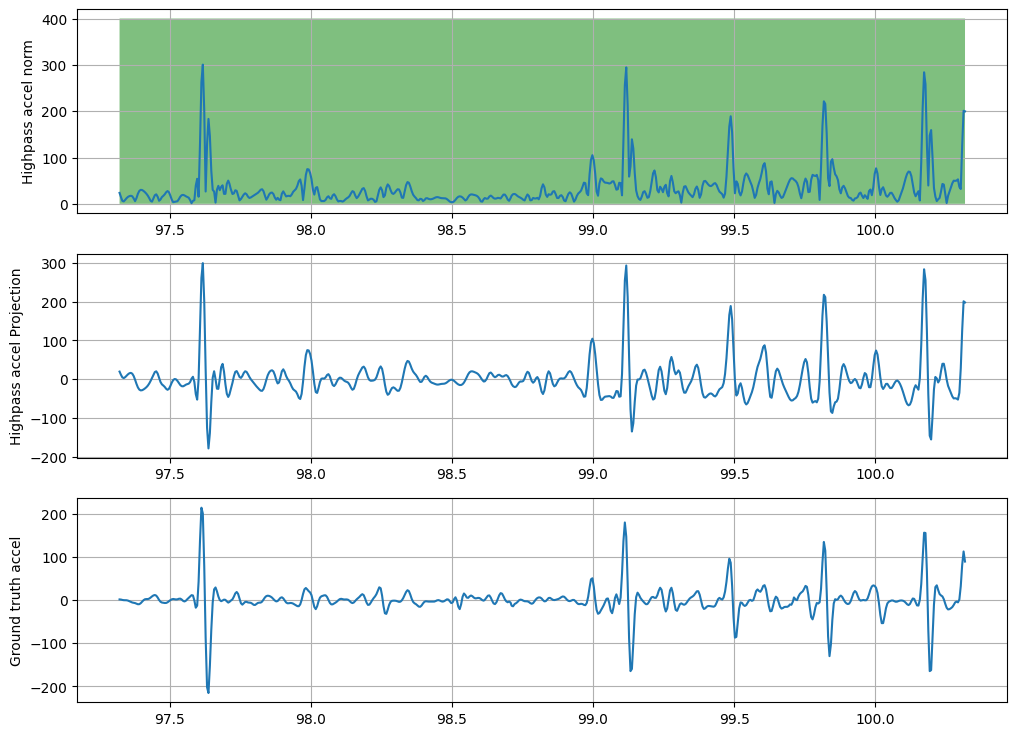

In [75]:
# Highpass accel and project
hp_fc_hz=2
sos_hp = butter(N=2, Wn=hp_fc_hz, btype="high", fs=200, output="sos")
a_hp = sosfiltfilt(sos_hp, a, axis=0)
a_hp_norm, a_hp_theta, a_hp_phi = get_polar(a_hp)

mask = (a_hp_norm > 10)
# dilate mask
mask = np.convolve(mask, np.ones(200), mode="same") > 0

gt_accel_axis = np.mean(a_hp * a_gt[:, np.newaxis], axis=0)
gt_accel_axis /= np.linalg.norm(gt_accel_axis)
print("Travel-correlated accel axis:", gt_accel_axis)
# Find main axis of acceleration
a_hp_m = a_hp[mask]
accel_axis = np.mean(a_hp_m[a_hp_m[:, 1] < 0], axis=0)
accel_axis /= np.linalg.norm(accel_axis)
print("Main accel axis:", accel_axis)
a_hp_proj = a_hp @ accel_axis
a_proj = a @ accel_axis

acc_err = a_hp_proj - a_gt
print("Accel MA, RMS:", np.mean(np.abs(a_gt)), np.sqrt(np.mean(a_gt**2)))
print("Accel error MAE, RMSE:", np.mean(np.abs(acc_err)), np.sqrt(np.mean(acc_err**2)))

plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
plt.plot(t[roi], a_hp_norm[roi])
plt.ylabel("Highpass accel norm")
plt.fill_between(t[roi], 400, where=mask[roi], facecolor='green', alpha=.5)
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], a_hp_proj[roi])
plt.ylabel("Highpass accel Projection")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_gt[roi])
plt.ylabel("Ground truth accel")
plt.grid()

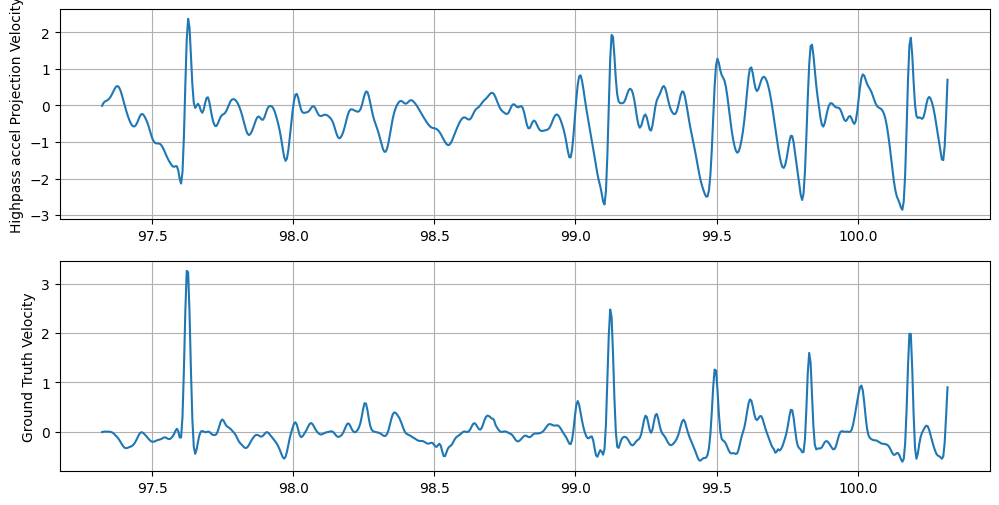

In [76]:
# Integrate accel to get velocity and plot
v = scipy.integrate.cumulative_trapezoid(a_hp_proj, t, initial=0)
v -= np.mean(v)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t[roi], v[roi])
plt.ylabel("Highpass accel Projection Velocity")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(t[roi], v_gt[roi] / 1000)
plt.ylabel("Ground Truth Velocity")
plt.grid()

Mean V at ZV: 34.12257427771326


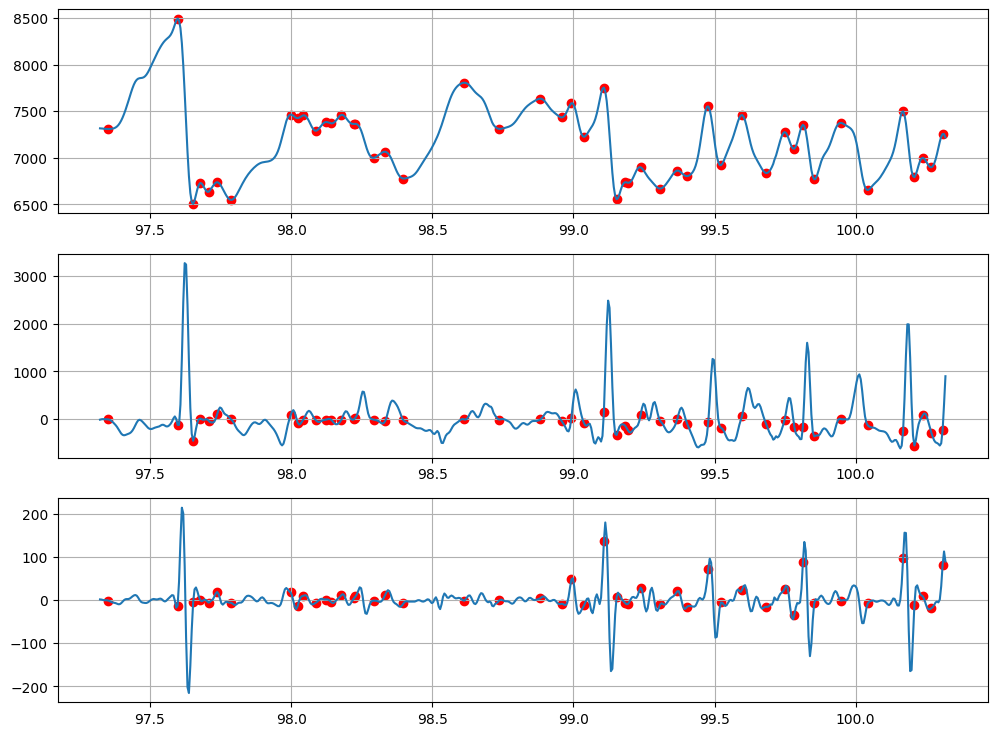

In [113]:
#mag_zv_points = ws["mag_zv_points"]

local_max_indices = (np.diff(np.sign(np.diff(b_proj))) < 0).nonzero()[0] + 1
local_min_indices = (np.diff(np.sign(np.diff(b_proj))) > 0).nonzero()[0] + 1
mag_zv_points = np.sort(np.concatenate((local_max_indices, local_min_indices)))
print("Mean V at ZV:", np.mean(np.abs(v_gt[mag_zv_points])))
plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
mag_zv_points_roi = (mag_zv_points > roi.start) & (mag_zv_points < roi.stop)
mag_zv_points_roi = mag_zv_points[mag_zv_points_roi] - roi.start
plt.plot(t[roi], b_proj[roi])
plt.scatter(t[roi][mag_zv_points_roi], b_proj[roi][mag_zv_points_roi], color="red")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], v_gt[roi])
plt.scatter(t[roi][mag_zv_points_roi], v_gt[roi][mag_zv_points_roi], color="red")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_gt[roi])
plt.scatter(t[roi][mag_zv_points_roi], a_gt[roi][mag_zv_points_roi], color="red")
plt.grid()

In [125]:
# Get pairs of zv points
min_dt = 0.1
max_dt = 0.2
min_db = 100
pairs = []
rejects = {"min_dt": 0, "max_dt": 0, "min_db": 0}
idx_1 = 0
while idx_1 < len(mag_zv_points) - 1:
    zv_1 = mag_zv_points[idx_1]
    for idx_2 in range(idx_1 + 1, len(mag_zv_points)):
        zv_2 = mag_zv_points[idx_2]
        dt = t[zv_2] - t[zv_1]
        db = b_proj[zv_2] - b_proj[zv_1]
        if dt > max_dt:
            rejects["max_dt"] += 1
            idx_1 += 1
            break
        if dt < min_dt:
            rejects["min_dt"] += 1
            continue
        if abs(db) < min_db:
            rejects["min_db"] += 1
            continue
        pairs.append((zv_1, zv_2))
        idx_1 = idx_2
        break
    else:
        idx_1 += 1
print(len(mag_zv_points))
print(rejects)
print(len(pairs))

17026
{'min_dt': 28350, 'max_dt': 11256, 'min_db': 27698}
2283


In [115]:
# Iterate through the pairs and integrate accel
acc = a_hp_proj

vs = []
xs = []
accs = []
slices = []

for (i1, i2) in pairs:
    chunk_slice = slice(i1, i2+1)
    t_chunk = t[chunk_slice]
    t_rel = t_chunk - t_chunk[0]
    a_raw = acc[chunk_slice] * 1000  # if you want mm/s^2
    bias = scipy.integrate.trapezoid(a_raw, t_rel) / t_rel[-1]
    #bias = np.mean(a_raw)
    a_chunk = a_raw - bias
    v_chunk = scipy.integrate.cumulative_trapezoid(a_chunk, t_chunk, initial=0)
    x_chunk = scipy.integrate.cumulative_trapezoid(v_chunk, t_chunk, initial=0)
    b_chunk = b_proj[chunk_slice]
    b_gradient = np.gradient(b_chunk, t_chunk, edge_order=2)
    
    if np.max(x_chunk) - np.min(x_chunk) < 10:
        continue
    vs.append(v_chunk)
    xs.append(x_chunk)
    slices.append(chunk_slice)
    accs.append(a_chunk)

Mean accel error: 19.887471172187155
Mean abs velocity error: 290.45688430392966
Mean position error: 14.752318086594908
Mean abs position error: 23.25454989756183
Mean abs position: 14.20978949517162
Correlation to error correlation 0.494417881961288


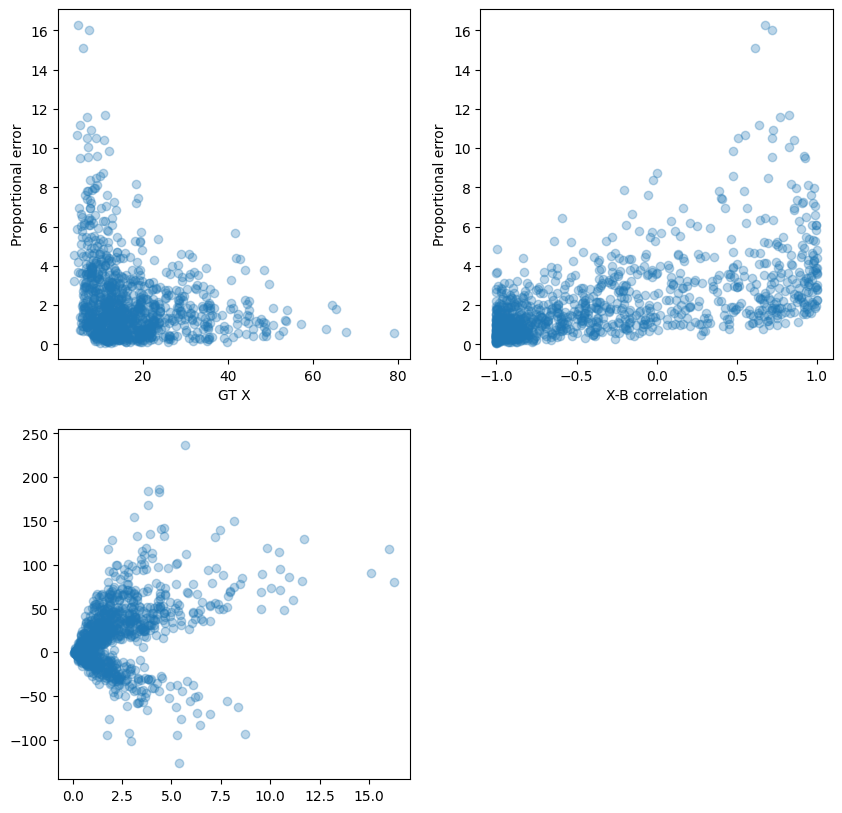

In [116]:
# Error statistics
v_gts = []
x_gts = []
v_errs = []
x_errs = []
abs_x_errs = []
b_chunks = []
x_b_corrs = []
acc_errs = []
x_prop_errs = []
for chunk_slice, v_chunk, x_chunk, a_chunk in zip(slices, vs, xs, accs):
    v_gt_chunk = v_gt[chunk_slice]
    v_err = v_chunk - v_gt_chunk
    x_gt_chunk = travel[chunk_slice] - travel[chunk_slice][0]
    x_err = x_chunk - x_gt_chunk
    b_chunk = b_proj[chunk_slice]
    x_b_corr = scipy.stats.spearmanr(x_chunk, b_chunk).correlation
    acc_err = (a_chunk / 1000) - a_gt[chunk_slice]
    #x_b_corr = scipy.stats.pearsonr(x_chunk, b_chunk)[0]

    x_gts.append(np.mean(np.abs(x_gt_chunk)))
    v_errs.append(np.mean(v_err))
    x_errs.append(np.mean(x_err))
    x_prop_errs.append(np.mean(np.abs(x_err)) / np.mean(np.abs(x_gt_chunk)))
    abs_x_errs.append(np.mean(np.abs(x_err)))
    x_b_corrs.append(x_b_corr)
    acc_errs.append(np.mean(np.abs(acc_err)))

mean_acc_err = np.median(acc_errs)
print("Mean accel error:", mean_acc_err)
mean_verr = np.median(np.abs(v_errs))
print("Mean abs velocity error:", mean_verr)
mean_xerr = np.median(x_errs)
print("Mean position error:", mean_xerr)
meanabs_xerr = np.median(np.abs(x_errs))
print("Mean abs position error:", meanabs_xerr)
meanabs_x = np.median(np.abs(x_gts))
print("Mean abs position:", meanabs_x)

print("Correlation to error correlation", scipy.stats.spearmanr(x_b_corrs, abs_x_errs).correlation)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(x_gts, x_prop_errs, alpha=0.3)
plt.xlabel("GT X")
plt.ylabel("Proportional error")
plt.subplot(2, 2, 2)
plt.scatter(x_b_corrs, x_prop_errs, alpha=0.3)
plt.xlabel("X-B correlation")
plt.ylabel("Proportional error")
plt.subplot(2, 2, 3)
plt.scatter(x_prop_errs, x_errs, alpha=0.3)

Text(0, 0.5, 'Position GT')

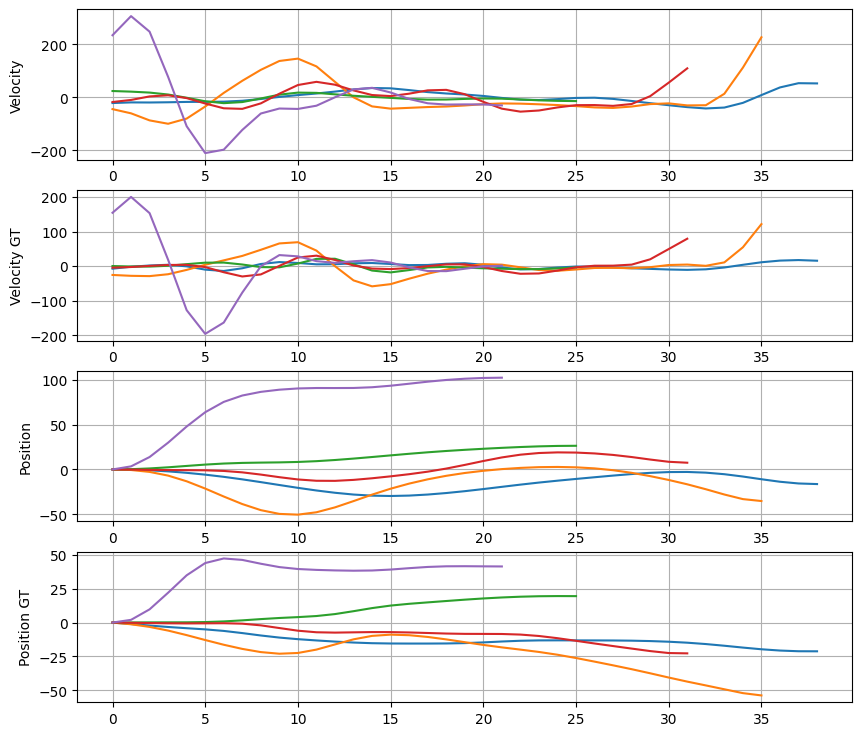

In [117]:
# Plot chunks
plt_chunks = 5
plt_idxes = np.random.randint(0, len(vs) + 1, plt_chunks)
plt.figure(figsize=(10, 9))
plt.subplot(4, 1, 1)
for i in plt_idxes:
    plt.plot(acc[slices[i]] - np.mean(acc[slices[i]]))
plt.grid()
plt.ylabel("Velocity")
plt.subplot(4, 1, 2)
for i in plt_idxes:
    plt.plot(a_gt[slices[i]])
plt.grid()
plt.ylabel("Velocity GT")
plt.subplot(4, 1, 3)
for i in plt_idxes:
    plt.plot(xs[i])
plt.grid()
plt.ylabel("Position")
plt.subplot(4, 1, 4)
for i in plt_idxes:
    plt.plot(travel[slices[i]] - travel[slices[i]][0])
plt.grid()
plt.ylabel("Position GT")

In [118]:
model_builder = MagToTravelModelCore(
    train_with_mask=False, 
    chunk_min_dx=10, 
    dm_dx_thresh=None,
    power_weight=0,
    chunk_max_dx=100,
    chunk_len=10
)

training_data = model_builder.create_training_data(
    b_proj, 
    acc,
    np.zeros_like(acc), 
    t,
    0,
    mag_zv_points
)

chunks: list[MagToTravelChunk] = model_builder.chunks
filts = model_builder.stats["chunks_filtered"]

print(len(chunks), " chunks for training")
print(filts)

Training chunks: 5213
Using raw min mag 0 chunks 5213
Min mag at indices: 5695.190689941151 mean 7320.934942311771 max 9067.757259276725
(5213, 2, 20)
5213  chunks for training
{'mask': 0, 'dx': 11812, 'dm/dx': 0, 'mag': 0}


In [119]:
result = model_builder.train(training_data, power_prior=1/3)
print("x0, y_scale, power:", result.x)

The maximum number of function evaluations is exceeded.
Function evaluations 1000, initial cost 1.0550e+07, final cost 9.9182e+06, first-order optimality 1.37e+03.
x0, y_scale, power: [ 0.01373614  8.95427273 -0.11085652]


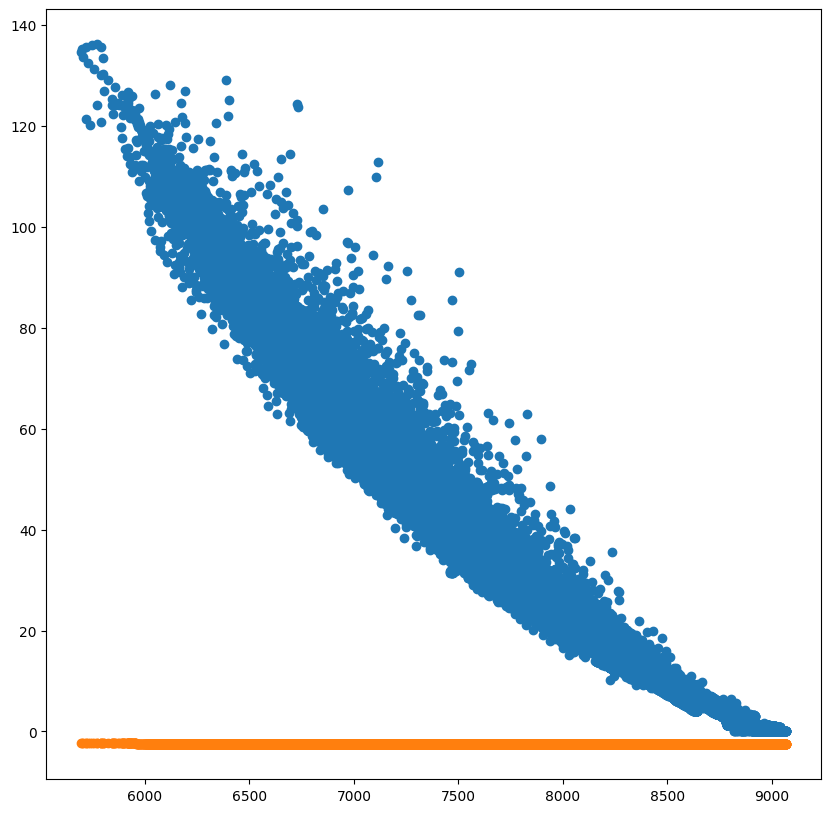

In [120]:
x_preds = model_builder.model.pred_x(b_proj)
plt.figure(figsize=(10, 10))
plt.scatter(b_proj, travel)
plt.scatter(b_proj, x_preds)

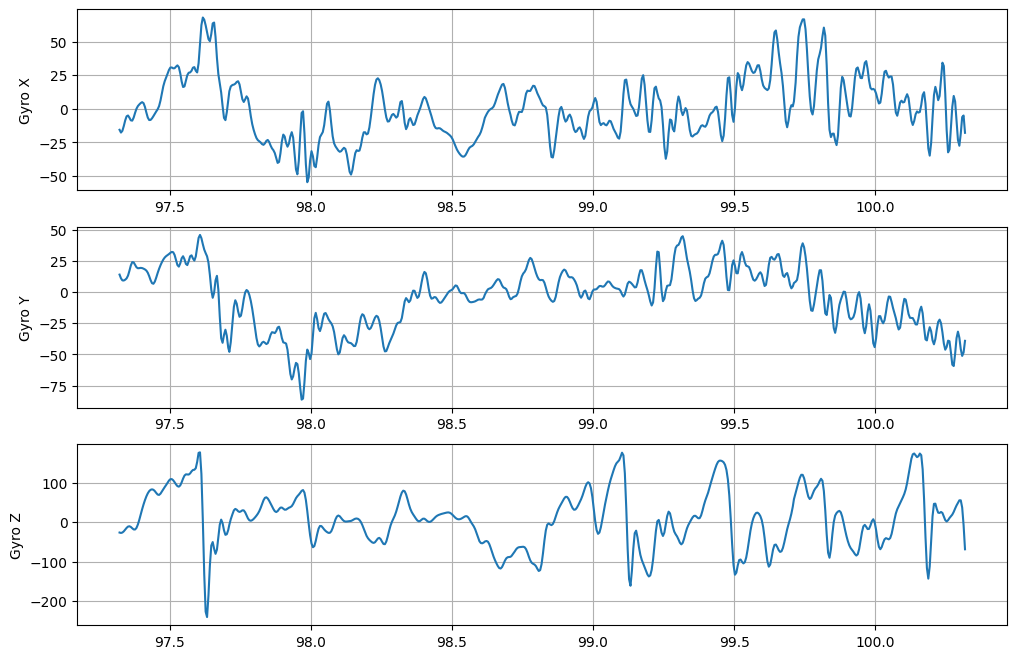

In [121]:
# Plot gyro
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t[roi], gyro[:, 0][roi])
plt.ylabel("Gyro X")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], gyro[:, 1][roi])
plt.ylabel("Gyro Y")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], gyro[:, 2][roi])
plt.ylabel("Gyro Z")
plt.grid()

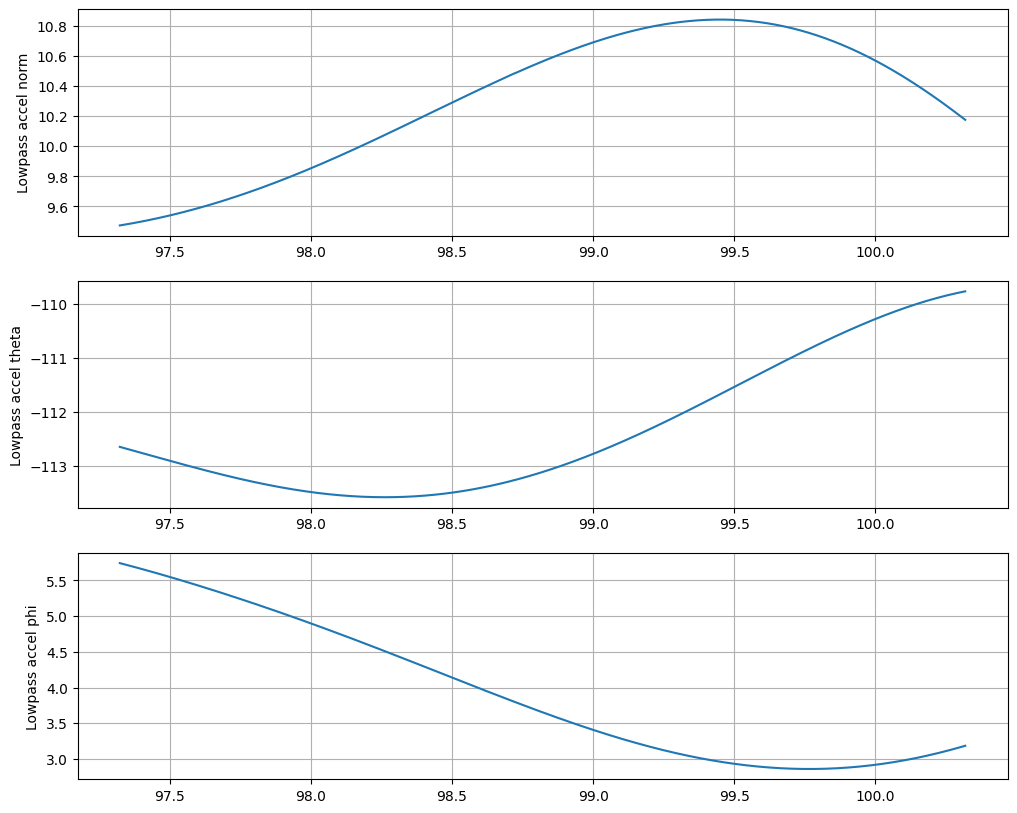

In [122]:
# Lowpass and plot accel
lp_fc_hz=0.25
sos_lp = butter(N=4, Wn=lp_fc_hz, btype="low", fs=200, output="sos")
a_lp = sosfiltfilt(sos_lp, a, axis=0)
a_lp_norm, a_lp_theta, a_lp_phi = get_polar(a_lp)

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(t[roi], a_lp_norm[roi])
plt.ylabel("Lowpass accel norm")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], a_lp_theta[roi])
plt.ylabel("Lowpass accel theta")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_lp_phi[roi])
plt.ylabel("Lowpass accel phi")
plt.grid()

In [123]:
# Figure out gyro and accel projection axes
gyro_m = gyro[mask]
gyro_axis = np.mean(gyro_m[gyro_m[:, 2] > 0], axis=0)
gyro_axis /= np.linalg.norm(gyro_axis)

gyro_proj = (gyro @ gyro_axis)

gyro_a_corr = scipy.stats.pearsonr(gyro_proj[mask], v[mask])
print(f"Correlation between accel and gyro projections: {gyro_a_corr[0]:.3f} (p={gyro_a_corr[1]:.3e})")

gyro_a_vector = np.mean(gyro * v[:, np.newaxis], axis=0)
gyro_a_vector /= np.linalg.norm(gyro_a_vector)

a_gyro_vector = np.mean(a_hp * gyro_proj[:, np.newaxis], axis=0)
a_gyro_vector /= np.linalg.norm(a_gyro_vector)

print(f"Gyro-accel vector correlation: {gyro_a_vector}")
print(gyro_axis)
#gyro_proj = gyro @ gyro_a_vector
print(f"Accel-gyro vector correlation: {a_gyro_vector}")
print(accel_axis)
#a_proj = a @ a_gyro_vector


Correlation between accel and gyro projections: -0.672 (p=0.000e+00)
Gyro-accel vector correlation: [ 0.04461791  0.02058706 -0.99879198]
[-0.07837486 -0.03907693  0.99615781]
Accel-gyro vector correlation: [-0.80740231 -0.57505909  0.13194148]
[-0.25681215 -0.96585725  0.03416576]


In [124]:
# Correlate mag to accel and gyro
db_norm = np.gradient(b1_mag, t, edge_order=2)
db_corr_norm = np.gradient(b_corr_mag, t, edge_order=2)
#db_proj = np.gradient(b_proj, t, edge_order=2)
v_m = v[mask]
gyro_proj_m = gyro_proj[mask]

for series, name in zip([db_norm, db_corr_norm], ["Mag norm", "Mag corr norm"]):
    corr_a = scipy.stats.pearsonr(series[mask], v[mask])
    corr_g = scipy.stats.pearsonr(series[mask], gyro_proj[mask])
    spearman_a = scipy.stats.spearmanr(series[mask], v[mask])
    spearman_g = scipy.stats.spearmanr(series[mask], gyro_proj[mask])
    print(f"Correlation between {name} and accel projection velocity: {corr_a[0]:.3f} (Spearman: {spearman_a.correlation:.3f})")
    print(f"Correlation between {name} and gyro projection: {corr_g[0]:.3f} (Spearman: {spearman_g.correlation:.3f})")

Correlation between Mag norm and accel projection velocity: -0.568 (Spearman: -0.463)
Correlation between Mag norm and gyro projection: 0.479 (Spearman: 0.403)
Correlation between Mag corr norm and accel projection velocity: -0.555 (Spearman: -0.451)
Correlation between Mag corr norm and gyro projection: 0.452 (Spearman: 0.367)
